## Telco Churn Project

### 1. Dependencies and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from scipy.stats import chi2_contingency
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

### 2. EDA

In [2]:
# loading the data

telco_df = pd.read_csv(R".\archive\WA_Fn-UseC_-Telco-Customer-Churn.csv")
telco_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
telco_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
telco_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# checking missing values
telco_df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# checking class balance of the target
print(telco_df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


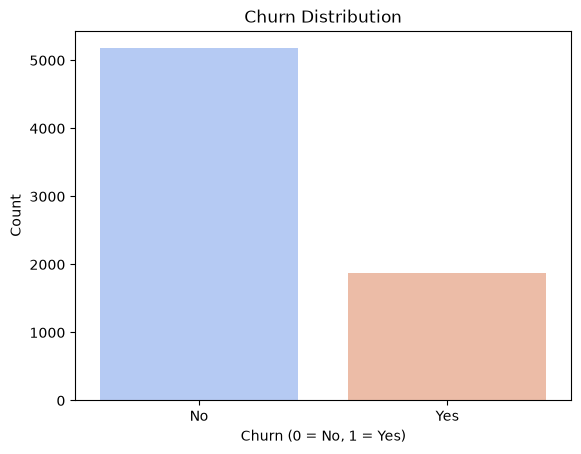

In [7]:
# checking target distribution

sns.countplot(x='Churn', data=telco_df, palette='coolwarm', hue='Churn',legend=False)
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [8]:
categorical_columns = telco_df.select_dtypes(include=['str', 'category'])
categorical_columns.columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

In [9]:
# "TotalCharges" column should be numerical but is detected as categorical 

print(telco_df["TotalCharges"].dtype)

# Replacing empty strings or whitespace-only strings with NaN
telco_df["TotalCharges"] = telco_df["TotalCharges"].replace(r'^\s*$', pd.NA, regex=True)

# converting valid numbers to numeric type and invalid values to NaN.
telco_df["TotalCharges"] = pd.to_numeric(telco_df["TotalCharges"], errors='coerce')

print("After data Cleaning:/n")
print(telco_df["TotalCharges"].dtype)

str
After data Cleaning:/n
float64


In [10]:
telco_df.drop("customerID",axis=1,inplace=True)
telco_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# numerical : correlation

# numerical columns
telco_df['Churn'] = telco_df['Churn'].map({'Yes': 1, 'No': 0})  # decode for correlation

# selecting numerical columns
numerical_cols = telco_df.select_dtypes(include=[np.number]).columns.tolist()

print("Numerical columns detected:/n", numerical_cols)

# correlation matrix
correlation_matrix = telco_df[numerical_cols].corr()
correlation_matrix

Numerical columns detected:/n ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.016567,0.220173,0.102411,0.150889
tenure,0.016567,1.000000,0.247900,0.825880,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651065,0.193356
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484
Churn,0.150889,-0.352229,0.193356,-0.199484,1.000000


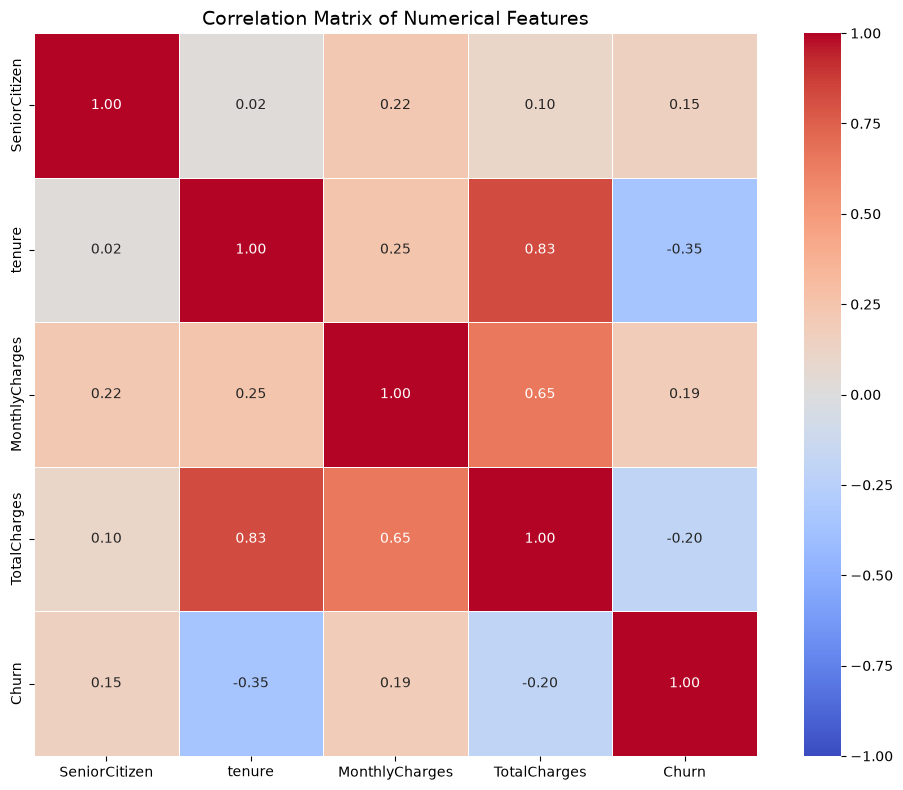

In [12]:
# confusion matrix heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,        
    fmt='.2f',         
    cmap='coolwarm',   # red = positive, blue = negative
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# unique value counts in categorical features

cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

bin_cols = []
mult_cols = []

for col in cat_cols:
    print(f"{col}: {telco_df[col].unique()}")
    if len(telco_df[col].unique()) ==2:
        bin_cols.append(col)
    else:
        mult_cols.append(col)

gender: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: 

In [14]:
# chi-square ranking

results = []

for col in cat_cols:
    table = pd.crosstab(telco_df[col], telco_df['Churn'])
    chi2, p, dof, expected = chi2_contingency(table)
    results.append({'feature': col, 'p_value': p})

chi_df = pd.DataFrame(results).sort_values('p_value')
print(chi_df)

             feature        p_value
12          Contract  5.863038e-258
6     OnlineSecurity  2.661150e-185
9        TechSupport  1.443084e-180
5    InternetService  9.571788e-160
14     PaymentMethod  3.682355e-140
7       OnlineBackup  2.079759e-131
8   DeviceProtection  5.505219e-122
11   StreamingMovies   2.667757e-82
10       StreamingTV   5.528994e-82
13  PaperlessBilling   4.073355e-58
2         Dependents   4.924922e-43
1            Partner   2.139911e-36
4      MultipleLines   3.464383e-03
3       PhoneService   3.387825e-01
0             gender   4.865787e-01


In [15]:
# decision for keeping the related features

alpha = 0.05    # decision threshold
selected_features = chi_df[chi_df['p_value'] < alpha]['feature'].tolist()
dropped_features = [f for f in chi_df['feature'] if f not in selected_features]

print("Features to keep:", selected_features)
print("Features to drop:", dropped_features)

# filtering main dataframe
final_categorical_cols = selected_features

Features to keep: ['Contract', 'OnlineSecurity', 'TechSupport', 'InternetService', 'PaymentMethod', 'OnlineBackup', 'DeviceProtection', 'StreamingMovies', 'StreamingTV', 'PaperlessBilling', 'Dependents', 'Partner', 'MultipleLines']
Features to drop: ['PhoneService', 'gender']


#### It is shown that "gender" and "PhoneService" columns are considered noise for the target and are not included in the final training features

In [16]:
# Cramer's V ranking

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))

cv_results = []

for col in final_categorical_cols:
    score = cramers_v(telco_df[col], telco_df['Churn'])
    cv_results.append({'feature': col, 'cramers_v': score})

cv_df = pd.DataFrame(cv_results).sort_values('cramers_v', ascending=False)
print(cv_df)

             feature  cramers_v
0           Contract   0.410116
1     OnlineSecurity   0.347400
2        TechSupport   0.342916
3    InternetService   0.322455
4      PaymentMethod   0.303359
5       OnlineBackup   0.292316
6   DeviceProtection   0.281580
7    StreamingMovies   0.230951
8        StreamingTV   0.230502
9   PaperlessBilling   0.191498
10        Dependents   0.163870
11           Partner   0.150126
12     MultipleLines   0.040109


#### "MultipleLines" column is also not included in the training process

In [17]:
dropped_features.append("MultipleLines")

cleaned_df = telco_df.drop(dropped_features, axis=1)

#### Results do not show strong linear relationships for churn, so mutual information is used to detect all types of relationships

In [18]:
# train/test split is done in this part to avoid data leakage

from sklearn.model_selection import train_test_split

X = cleaned_df.drop('Churn', axis=1)
y = cleaned_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# creating a copy of x_train for using in MI
X_train_mi = X_train.copy()

In [19]:
# filling missing values in "TotalCharges" column for MI with median value

#filling with median
median_value = X_train_mi["TotalCharges"].median()

# Fill missing values
X_train_mi["TotalCharges"] = X_train_mi["TotalCharges"].fillna(median_value)

In [20]:
# categorical encoding function

def cat_encode(df, dropped_features, bin_cols, mult_cols):
    for feat in dropped_features:
        if feat in bin_cols:
            bin_cols.remove(feat)

        if feat in mult_cols:
            mult_cols.remove(feat)

    # mapping binary columns 
    for col in bin_cols:    
        df[col] = df[col].map({'Yes':1, 'No': 0})

    # mapping multi-categorical columns
    df = pd.get_dummies(df, columns=mult_cols, drop_first=True)

    # Convert all True/False columns (created by get_dummies) to 1/0
    df = df.astype(int)

    return df

In [21]:
# Encoding categorical features for MI

X_train_mi = cat_encode(X_train_mi, dropped_features, bin_cols, mult_cols)
X_train_mi.head()

,SeniorCitizen,Partner,Dependents,tenure,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0,0,0,35,0,49,1701,0,0,0,...,0,0,1,0,1,0,0,0,1,0
3151,0,1,1,15,0,75,1151,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4860,0,1,1,13,0,40,590,0,0,0,...,1,0,0,0,0,0,1,0,0,1
3867,0,1,0,26,1,73,1905,0,0,0,...,0,0,1,0,1,0,1,1,0,0
3810,0,1,1,1,0,44,44,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [22]:
from sklearn.feature_selection import mutual_info_classif

# finding out which columns are discrete
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
discrete_features = [col not in num_cols for col in X_train_mi.columns]

In [23]:
# Mutual Information Calculation

mi_scores = mutual_info_classif(X_train_mi, y_train, discrete_features=discrete_features, random_state=42)

# ranking
mi_results = pd.Series(mi_scores, name="MI Scores", index=X_train_mi.columns).sort_values(ascending=False)

print("Final Feature Ranking (Mutual Information):")
print(mi_results)

Final Feature Ranking (Mutual Information):
tenure                                   0.079042
Contract_Two year                        0.060477
MonthlyCharges                           0.050108
InternetService_Fiber optic              0.049318
PaymentMethod_Electronic check           0.046062
TotalCharges                             0.033395
DeviceProtection_No internet service     0.031754
OnlineBackup_No internet service         0.031754
InternetService_No                       0.031754
OnlineSecurity_No internet service       0.031754
StreamingTV_No internet service          0.031754
StreamingMovies_No internet service      0.031754
TechSupport_No internet service          0.031754
PaperlessBilling                         0.020481
Contract_One year                        0.018448
OnlineSecurity_Yes                       0.016538
Dependents                               0.015082
TechSupport_Yes                          0.014789
Partner                                  0.010735
Paymen

In [24]:
# detecting the last 5 columns from training features based on MI

low_mi = ['PaymentMethod_Mailed check',
            'OnlineBackup_Yes',
            'DeviceProtection_Yes',
            'StreamingTV_Yes',
            'StreamingMovies_Yes']

### 3. Preprocessing

In [25]:
# filling missing values in "TotalCharges" column

median_value_train = X_train["TotalCharges"].median()
X_train["TotalCharges"] = X_train["TotalCharges"].fillna(median_value_train)

median_value_test = X_test["TotalCharges"].median()
X_test["TotalCharges"] = X_test["TotalCharges"].fillna(median_value_test)

In [26]:
# encoding features

X_train = cat_encode(X_train, dropped_features, bin_cols, mult_cols)
X_test = cat_encode(X_test, dropped_features, bin_cols, mult_cols)

In [27]:
X_train_clean = X_train.drop(columns= low_mi)

# Aligning columns across all features
X_test = X_test.reindex(columns=X_train_clean.columns, fill_value=0)

In [28]:
# saving training columns for streamlit app
training_columns = X_train_clean.columns.tolist()

In [29]:
# scaling numerical features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train_clean.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train_clean[num_cols])

X_test_scaled = X_test.copy()
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

### 4. Model Selection

#### 4-1. Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression


LR_model = LogisticRegression(max_iter=1000,
                                       class_weight='balanced',
                                       random_state=42)

LR_model.fit(X_train_scaled,y_train)

y_pred_balanced = LR_model.predict(X_test_scaled)

# evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.7366926898509581

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



#### 4-2. Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', # balanced target distribution
    random_state=42,
    max_depth=6
)

rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7466288147622427

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.51      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



#### 4-3. XGBoost

In [32]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("\nXGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.8026969481902059

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



### 5. Fine-Tuning

#### 5-1. Threshold Tuning

In [33]:
# threshold tuning on Logistic Regression

y_prob = LR_model.predict_proba(X_test_scaled)[:, 1]

threshold = [0.3, 0.4, 0.5, 0.6]

for th in threshold:
    y_pred_thr = (y_prob >= th).astype(int)

    from sklearn.metrics import classification_report, accuracy_score

    print("Threshold:", th)
    print("Accuracy:", accuracy_score(y_test, y_pred_thr))
    print(classification_report(y_test, y_pred_thr))
    print(53*"*")

Threshold: 0.3
Accuracy: 0.6458481192334989
              precision    recall  f1-score   support

           0       0.95      0.55      0.69      1035
           1       0.42      0.92      0.58       374

    accuracy                           0.65      1409
   macro avg       0.69      0.73      0.64      1409
weighted avg       0.81      0.65      0.66      1409

*****************************************************
Threshold: 0.4
Accuracy: 0.6990773598296665
              precision    recall  f1-score   support

           0       0.93      0.64      0.76      1035
           1       0.46      0.86      0.60       374

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.80      0.70      0.72      1409

*****************************************************
Threshold: 0.5
Accuracy: 0.7366926898509581
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      10

#### 5-2. Hyperparameter Tuning on Models

##### 5_2.1. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_reg = LogisticRegression(max_iter=1000, random_state=42)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_lr,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_scaled, y_train)

print("Best LR params:", grid_lr.best_params_)
print("Best CV score:", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_
lr_probs = best_lr.predict_proba(X_test_scaled)[:, 1]
lr_preds = (lr_probs >= 0.4).astype(int)

print(confusion_matrix(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best LR params: {'C': 1, 'class_weight': None, 'solver': 'liblinear'}
Best CV score: 0.7306811831891464
[[846 189]
 [126 248]]
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.66      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



##### 5_2.2. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42, class_weight='balanced',)

param_grid_rf = {
    'n_estimators': [10,100],
    'max_depth': [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid_rf.fit(X_train_scaled, y_train)

print("Best RF params:", grid_rf.best_params_)
print("Best CV score:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_
rf_probs = best_rf.predict_proba(X_test)[:, 1]
rf_preds = (rf_probs >= 0.4).astype(int)

print(confusion_matrix(y_test, rf_preds))
print(classification_report(y_test, rf_preds))


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best RF params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best CV score: 0.732301029462131
[[903 132]
 [198 176]]
              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1035
           1       0.57      0.47      0.52       374

    accuracy                           0.77      1409
   macro avg       0.70      0.67      0.68      1409
weighted avg       0.75      0.77      0.76      1409



##### 5_2.3. XGBoost

In [36]:
# XGBoost

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Calculate class imbalance ratio for scale_pos_weight
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])


xgb_model = XGBClassifier(
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'scale_pos_weight': [1, ratio]  # ratio balances the classes
}


grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_macro', 
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Hyperparameters found:", grid_search.best_params_)
print("Best CV score:", grid_lr.best_score_)

best_xgb = grid_search.best_estimator_
xgb_probs = best_xgb.predict_proba(X_test_scaled)[:, 1]
xgb_preds = (xgb_probs >= 0.4).astype(int)

print(confusion_matrix(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))

Fitting 5 folds for each of 54 candidates, totalling 270 fits


c:\Users\jsmnk\OneDrive\Documents\Python\Projects\Churn IBM\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:11:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Hyperparameters found: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 1}
Best CV score: 0.7306811831891464
[[867 168]
 [130 244]]
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1035
           1       0.59      0.65      0.62       374

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409



### 6. Comparison

In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    'Logistic Regression': best_lr,
    'Random Forest': best_rf,
    'Tuned XGBoost': best_xgb
}

results = []
threshold = 0.4

for name, model in models.items():
    probs = model.predict_proba(X_test_scaled)[:, 1]
    preds = (probs >= threshold).astype(int)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (Class 1)': precision_score(y_test, preds),
        'Recall (Class 1)': recall_score(y_test, preds),
        'F1-Score (Class 1)': f1_score(y_test, preds)
    })

# Convert to DataFrame
comparison_df = pd.DataFrame(results)
print("\nModel Comparison at Threshold = 0.4:")
print(comparison_df.to_string(index=False))


Model Comparison at Threshold = 0.4:
              Model  Accuracy  Precision (Class 1)  Recall (Class 1)  F1-Score (Class 1)
Logistic Regression  0.776437             0.567506          0.663102            0.611591
      Random Forest  0.731015             0.496000          0.828877            0.620621
      Tuned XGBoost  0.788502             0.592233          0.652406            0.620865


C:\Users\jsmnk\AppData\Local\Temp\ipykernel_14284\642228268.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


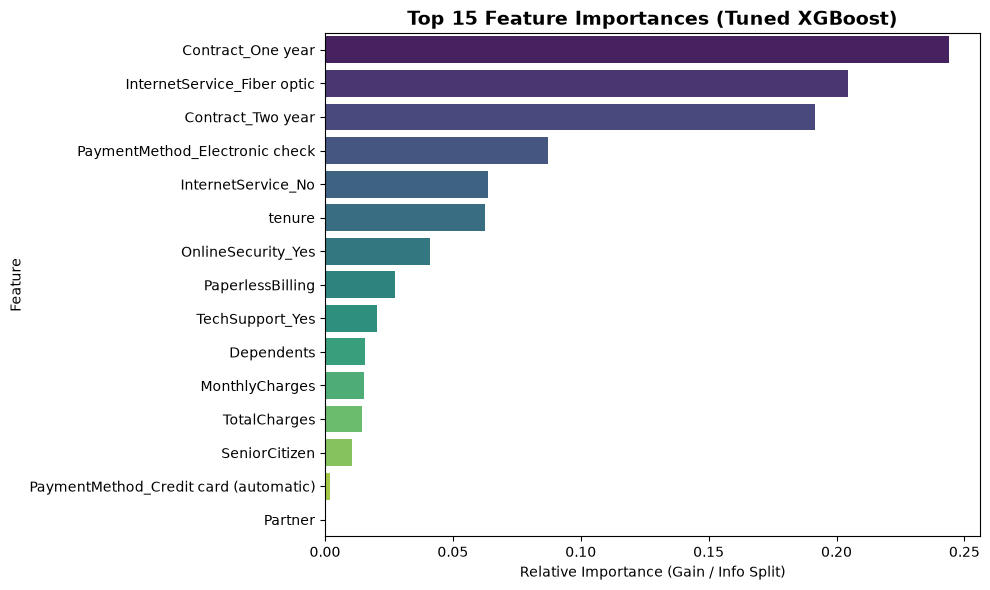

In [38]:
# feature importance

importances = best_xgb.feature_importances_
feature_names = X_train_clean.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feat_imp_df.head(15), 
    palette='viridis'
)
plt.title('Top 15 Feature Importances (Tuned XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (Gain / Info Split)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 7. Saving Data for Streamlit App

In [39]:
# saving artifacts for streamlit

import joblib
import json

joblib.dump(best_xgb, 'artifacts/best_xgb.pkl')
joblib.dump(scaler, 'artifacts/scaler.pkl')
joblib.dump(num_cols, "artifacts/numeric_cols.pkl")
joblib.dump(training_columns, "artifacts/training_columns.pkl")

['artifacts/training_columns.pkl']